# 5b - Interpretabilità dei modelli e analisi critica degli errori

Questo notebook approfondisce qualitativamente il comportamento dei modelli sviluppati per la previsione dell'esito delle partite di League of Legends.

L'analisi si concentra su tre aspetti principali:

1. confronto dell'importanza attribuita alle feature dalla Regressione Logistica e dalla Random Forest;
2. individuazione e analisi delle partite del Test Set classificate erroneamente da tutti i modelli;
3. discussione dei limiti intrinseci di una previsione effettuata utilizzando esclusivamente le informazioni disponibili al minuto 10.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Keep Out\File\Magistrale\predictLoL


## 1. Caricamento dei dati

Vengono caricati sia il Test Set standardizzato sia la corrispondente versione nelle unità originali. Le due rappresentazioni contengono le stesse osservazioni e le stesse feature, ma vengono utilizzate coerentemente con la rappresentazione adottata durante l'addestramento dei diversi modelli.

In [3]:
X_TEST_SCALED_PATH = PROJECT_ROOT / "data" / "X_test_scaled.csv"
X_TEST_PATH = PROJECT_ROOT / "data" / "X_test.csv"
Y_TEST_PATH = PROJECT_ROOT / "data" / "y_test.csv"

assert X_TEST_SCALED_PATH.exists(), f"File non trovato: {X_TEST_SCALED_PATH}"
assert X_TEST_PATH.exists(), f"File non trovato: {X_TEST_PATH}"
assert Y_TEST_PATH.exists(), f"File non trovato: {Y_TEST_PATH}"

X_test_scaled = pd.read_csv(X_TEST_SCALED_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH)["blueWins"]

print(f"X_test standardizzato: {X_test_scaled.shape}")
print(f"X_test non standardizzato: {X_test.shape}")
print(f"y_test: {y_test.shape}")

assert list(X_test_scaled.columns) == list(X_test.columns)

print("Le due rappresentazioni del Test Set contengono le stesse feature.")

X_test standardizzato: (1976, 27)
X_test non standardizzato: (1976, 27)
y_test: (1976,)
Le due rappresentazioni del Test Set contengono le stesse feature.


## 2. Confronto della Feature Importance

Regressione Logistica e Random Forest permettono di interpretare l'importanza delle feature attraverso meccanismi differenti.

Nella Regressione Logistica, il coefficiente associato a ciascuna feature determina intensità e direzione del suo contributo alla previsione. Poiché il modello è stato addestrato su feature standardizzate, la grandezza assoluta dei coefficienti può essere utilizzata per confrontarne il peso relativo.

La Random Forest assegna invece a ciascuna feature un valore di `feature_importances_`, che rappresenta quanto quella variabile contribuisce complessivamente alle decisioni effettuate dagli alberi dell'ensemble. Questi valori sono non negativi e non indicano direttamente se una feature favorisca la vittoria o la sconfitta del Blue Team.

In [4]:
MODELS_DIR = PROJECT_ROOT / "models"

logistic_model = joblib.load(MODELS_DIR / "logistic_regression.pkl")
random_forest_model = joblib.load(MODELS_DIR / "random_forest_best.pkl")

print(logistic_model)
print(random_forest_model)

LogisticRegression(C=0.01, l1_ratio=1, max_iter=2000, random_state=42,
                   solver='liblinear')
RandomForestClassifier(max_depth=5, max_features='log2', random_state=42)


In [5]:
logistic_importance = pd.DataFrame({
    "feature": X_test_scaled.columns,
    "logistic_coefficient": logistic_model.coef_[0],
})

logistic_importance["logistic_abs"] = (
    logistic_importance["logistic_coefficient"].abs()
)

logistic_importance = logistic_importance.sort_values(
    "logistic_abs",
    ascending=False
).reset_index(drop=True)

logistic_importance

,feature,logistic_coefficient,logistic_abs
0,blueGoldDiff,0.931549,0.931549
1,blueExperienceDiff,0.391609,0.391609
2,blueDragons,0.128523,0.128523
3,redDragons,-0.108023,0.108023
4,blueFirstBlood,0.000000,0.000000
5,blueDeaths,0.000000,0.000000
6,blueHeralds,0.000000,0.000000
7,blueTowersDestroyed,0.000000,0.000000
8,blueKills,0.000000,0.000000
9,blueWardsDestroyed,0.000000,0.000000


Il segno del coefficiente mantiene l'informazione sulla direzione dell'effetto: un coefficiente positivo è associato a una maggiore propensione del modello verso `blueWins = 1`, mentre un coefficiente negativo opera nella direzione opposta. Il valore assoluto viene invece utilizzato quando interessa confrontare esclusivamente l'intensità del contributo delle diverse feature.

In [6]:
random_forest_importance = pd.DataFrame({
    "feature": X_test_scaled.columns,
    "random_forest_importance": random_forest_model.feature_importances_,
})

random_forest_importance = random_forest_importance.sort_values(
    "random_forest_importance",
    ascending=False
).reset_index(drop=True)

random_forest_importance

,feature,random_forest_importance
0,blueGoldDiff,0.222395
1,blueExperienceDiff,0.169296
2,blueTotalGold,0.092707
3,redTotalGold,0.087704
4,blueGoldPerMin,0.077175
5,redTotalExperience,0.074265
6,redGoldPerMin,0.063139
7,blueAvgLevel,0.044893
8,blueTotalExperience,0.038871
9,redAvgLevel,0.029249


In [7]:
logistic_comparison = logistic_importance.copy()

logistic_comparison["logistic_relative_importance"] = (
    logistic_comparison["logistic_abs"]
    / logistic_comparison["logistic_abs"].sum()
)

importance_comparison = logistic_comparison.merge(
    random_forest_importance,
    on="feature"
)

importance_comparison = importance_comparison.sort_values(
    "random_forest_importance",
    ascending=False
).reset_index(drop=True)

importance_comparison[
    [
        "feature",
        "logistic_coefficient",
        "logistic_relative_importance",
        "random_forest_importance",
    ]
]

,feature,logistic_coefficient,logistic_relative_importance,random_forest_importance
0,blueGoldDiff,0.931549,0.597260,0.222395
1,blueExperienceDiff,0.391609,0.251079,0.169296
2,blueTotalGold,0.000000,0.000000,0.092707
3,redTotalGold,0.000000,0.000000,0.087704
4,blueGoldPerMin,0.000000,0.000000,0.077175
5,redTotalExperience,0.000000,0.000000,0.074265
6,redGoldPerMin,0.000000,0.000000,0.063139
7,blueAvgLevel,0.000000,0.000000,0.044893
8,blueTotalExperience,0.000000,0.000000,0.038871
9,redAvgLevel,0.000000,0.000000,0.029249


Per rendere più leggibile il confronto, il valore assoluto dei coefficienti della Regressione Logistica viene normalizzato in modo che la somma delle importanze relative sia pari a 1. Questa trasformazione non modifica la struttura del modello, ma consente di confrontare graficamente la distribuzione dell'importanza con quella prodotta dalla Random Forest. Il coefficiente originale con segno viene comunque mantenuto separatamente per interpretare la direzione dell'effetto.

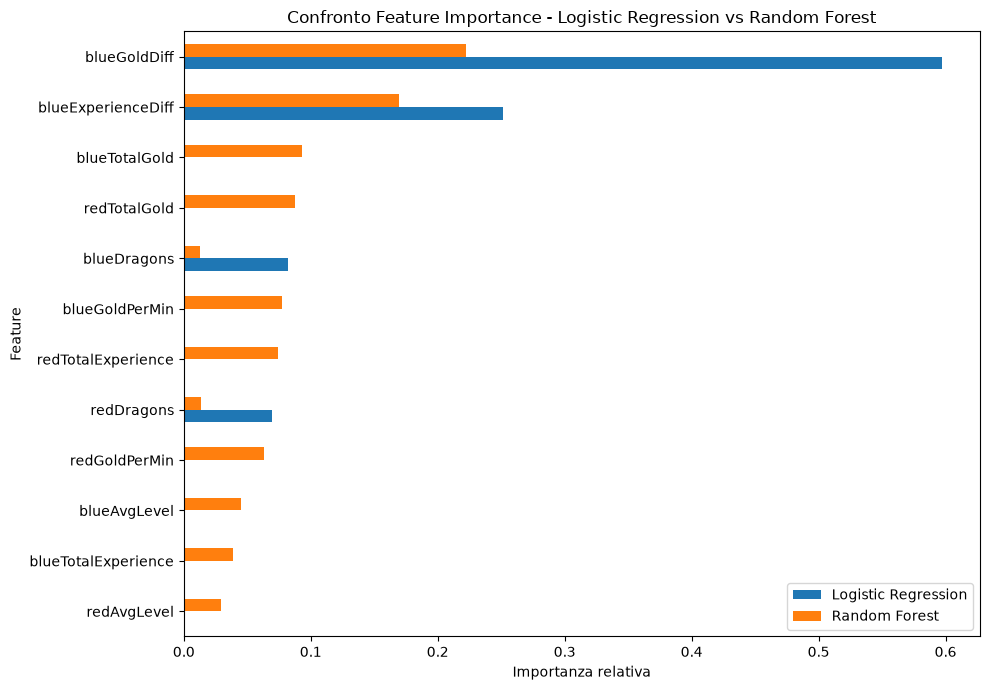

In [8]:
importance_comparison["max_importance"] = importance_comparison[
    ["logistic_relative_importance", "random_forest_importance"]
].max(axis=1)

top_features = (
    importance_comparison
    .sort_values("max_importance", ascending=False)
    .head(12)
    .sort_values("max_importance", ascending=True)
)

top_features.plot(
    x="feature",
    y=["logistic_relative_importance", "random_forest_importance"],
    kind="barh",
    figsize=(10, 7),
)

plt.xlabel("Importanza relativa")
plt.ylabel("Feature")
plt.title("Confronto Feature Importance - Logistic Regression vs Random Forest")
plt.legend(["Logistic Regression", "Random Forest"])
plt.tight_layout()
plt.show()

### Interpretazione del confronto

Il confronto evidenzia che entrambi i modelli attribuiscono un ruolo centrale al vantaggio economico e di esperienza maturato nei primi 10 minuti, ma distribuiscono l'importanza tra le feature in modo differente.

Nella **Regressione Logistica**, `blueGoldDiff` domina nettamente il modello e rappresenta circa il `59.7%` dell'importanza relativa complessiva, seguito da `blueExperienceDiff` con circa il `25.1%`. Le altre due feature con coefficiente diverso da zero sono `blueDragons` (`8.2%`) e `redDragons` (`6.9%`). Il coefficiente di `blueGoldDiff` è positivo, indicando che un maggiore vantaggio economico del Blue Team aumenta la propensione del modello verso la previsione `blueWins = 1`, mentre il coefficiente negativo di `redDragons` opera nella direzione opposta.

La forte concentrazione dell'importanza su sole quattro feature è collegata anche alla regolarizzazione **L1** utilizzata dalla Regressione Logistica, che tende ad annullare i coefficienti delle variabili che forniscono un contributo aggiuntivo limitato rispetto alle feature già selezionate. Un coefficiente pari a zero non implica quindi necessariamente che la corrispondente informazione di gioco sia priva di relazione con l'esito, ma che il modello lineare non la considera necessaria una volta tenuto conto delle feature selezionate.

La **Random Forest** attribuisce anch'essa la maggiore importanza a `blueGoldDiff` (`22.2%`) e `blueExperienceDiff` (`16.9%`), confermando la rilevanza dei vantaggi economici e di esperienza. Tuttavia, l'importanza viene distribuita su un numero maggiore di variabili, tra cui `blueTotalGold` (`9.3%`), `redTotalGold` (`8.8%`), `blueGoldPerMin` (`7.7%`), `redTotalExperience` (`7.4%`) e `redGoldPerMin` (`6.3%`).

La differenza è coerente con la struttura dei due algoritmi: la Regressione Logistica costruisce una relazione lineare e, grazie alla regolarizzazione L1, produce una rappresentazione molto selettiva; la Random Forest può invece sfruttare relazioni non lineari e interazioni tra più caratteristiche dello stato della partita. Le importanze della Random Forest possono inoltre distribuirsi tra feature che descrivono aspetti simili del gioco, come le diverse misure relative a oro ed esperienza.

Nel complesso, i due modelli convergono sulla stessa indicazione principale: **il differenziale di oro e il differenziale di esperienza al minuto 10 costituiscono i segnali più rilevanti per la previsione dell'esito finale**, mentre la Random Forest integra questa informazione con un insieme più ampio di risorse e statistiche dell'early game.

## 3. Analisi critica degli errori

Per individuare le osservazioni più difficili da classificare, vengono isolate le partite del Test Set per le quali tutti e sei i modelli producono una previsione errata.

La presenza di errori condivisi da algoritmi basati su principi molto differenti può indicare casi in cui le informazioni disponibili al minuto 10 non forniscono un segnale sufficientemente chiaro sull'esito finale della partita.

In [9]:
model_paths = {
    "Logistic Regression": MODELS_DIR / "logistic_regression.pkl",
    "SVM": MODELS_DIR / "svm.pkl",
    "Decision Tree": MODELS_DIR / "decision_tree.pkl",
    "KNN": MODELS_DIR / "knn_best.pkl",
    "Random Forest": MODELS_DIR / "random_forest_best.pkl",
    "Gaussian Naive Bayes": MODELS_DIR / "naive_bayes_best.pkl",
}

models = {
    model_name: joblib.load(model_path)
    for model_name, model_path in model_paths.items()
}

model_inputs = {
    "Logistic Regression": X_test_scaled,
    "SVM": X_test_scaled,
    "Decision Tree": X_test,
    "KNN": X_test_scaled,
    "Random Forest": X_test_scaled,
    "Gaussian Naive Bayes": X_test_scaled,
}

print(f"Modelli caricati: {len(models)}")

Modelli caricati: 6


In [10]:
predictions = {}

for model_name, model in models.items():
    predictions[model_name] = model.predict(
        model_inputs[model_name]
    )

print("Predizioni generate per tutti i modelli.")

Predizioni generate per tutti i modelli.


In [11]:
predictions_df = pd.DataFrame(
    predictions,
    index=y_test.index
)

wrong_predictions = predictions_df.ne(
    y_test,
    axis=0
)

all_wrong_mask = wrong_predictions.all(axis=1)

common_errors = X_test.loc[all_wrong_mask].copy()
common_errors["blueWins"] = y_test.loc[all_wrong_mask]

print(f"Partite nel Test Set: {len(X_test)}")
print(f"Partite sbagliate da tutti i modelli: {len(common_errors)}")
print(
    f"Percentuale sul Test Set: "
    f"{len(common_errors) / len(X_test) * 100:.2f}%"
)

Partite nel Test Set: 1976
Partite sbagliate da tutti i modelli: 391
Percentuale sul Test Set: 19.79%


In [12]:
common_errors.head(10)

,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,...,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldPerMin,blueWins
4,20,0,1,5,11,0,0,0,15453,6.6,...,0,0,0,18433,7.2,19173,233,45,1843.3,1
7,14,1,1,5,8,0,0,0,15747,7.0,...,0,0,0,17105,7.0,18919,219,52,1710.5,1
11,16,4,1,11,6,1,1,0,17816,7.4,...,0,0,0,16328,7.0,17534,225,48,1632.8,0
15,148,3,0,8,4,0,0,0,16600,7.2,...,1,0,0,14973,6.6,17209,194,64,1497.3,0
16,15,2,0,7,5,0,0,0,17450,7.0,...,0,0,0,16156,7.2,18346,213,58,1615.6,0
30,21,1,1,4,6,0,0,0,15338,7.0,...,0,0,0,16187,7.0,19014,234,46,1618.7,1
34,85,0,1,6,2,1,0,0,16440,7.0,...,0,0,0,13619,6.2,15663,203,46,1361.9,0
36,17,2,0,2,5,0,0,0,14981,7.0,...,1,0,0,16588,7.2,18815,259,48,1658.8,1
44,12,1,1,6,8,0,0,0,16560,7.0,...,1,0,0,16967,7.4,19331,223,52,1696.7,1
45,20,6,0,8,6,0,1,1,18909,7.2,...,1,0,0,15886,6.6,16728,211,44,1588.6,0


In [13]:
test_abs_gold_diff = X_test["blueGoldDiff"].abs()
error_abs_gold_diff = common_errors["blueGoldDiff"].abs()

gold_diff_comparison = pd.DataFrame({
    "Gruppo": [
        "Intero Test Set",
        "Errori comuni",
    ],
    "Numero partite": [
        len(X_test),
        len(common_errors),
    ],
    "Media |blueGoldDiff|": [
        test_abs_gold_diff.mean(),
        error_abs_gold_diff.mean(),
    ],
    "Mediana |blueGoldDiff|": [
        test_abs_gold_diff.median(),
        error_abs_gold_diff.median(),
    ],
    "% entro 500 gold": [
        (test_abs_gold_diff <= 500).mean() * 100,
        (error_abs_gold_diff <= 500).mean() * 100,
    ],
    "% entro 1000 gold": [
        (test_abs_gold_diff <= 1000).mean() * 100,
        (error_abs_gold_diff <= 1000).mean() * 100,
    ],
})

gold_diff_comparison.round(2)

,Gruppo,Numero partite,Media |blueGoldDiff|,Mediana |blueGoldDiff|,% entro 500 gold,% entro 1000 gold
0,Intero Test Set,1976,2005.26,1677.0,16.04,31.88
1,Errori comuni,391,1577.96,1367.0,14.07,36.32


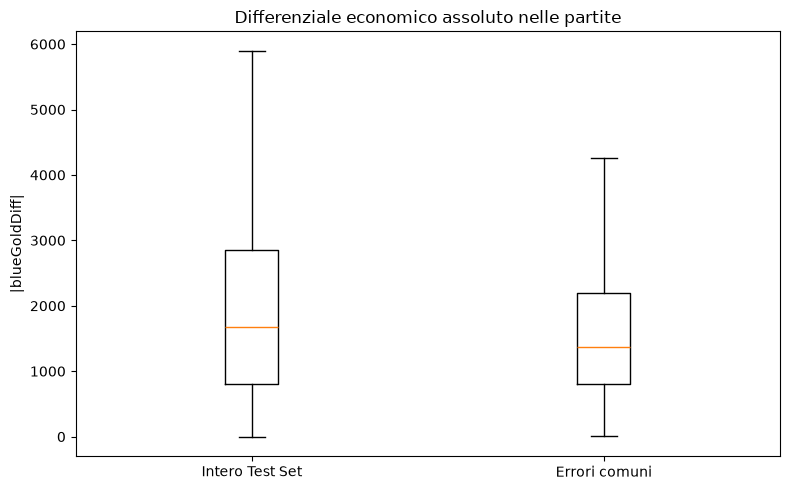

In [14]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        test_abs_gold_diff,
        error_abs_gold_diff,
    ],
    tick_labels=[
        "Intero Test Set",
        "Errori comuni",
    ],
    showfliers=False,
)

plt.ylabel("|blueGoldDiff|")
plt.title("Differenziale economico assoluto nelle partite")
plt.tight_layout()
plt.show()

### Analisi delle partite borderline

I sei classificatori sbagliano contemporaneamente `391` delle `1976` partite del Test Set, corrispondenti al `19.79%` delle osservazioni. La presenza di un numero consistente di errori condivisi da modelli basati su principi differenti suggerisce che una parte delle difficoltà di classificazione possa essere legata alle informazioni disponibili al minuto 10 e non esclusivamente alle caratteristiche di un singolo algoritmo.

L'analisi del valore assoluto di `blueGoldDiff` mostra che le partite sbagliate da tutti i modelli presentano mediamente un differenziale economico più contenuto. La media di `|blueGoldDiff|` passa infatti da circa `2005` gold nell'intero Test Set a circa `1578` gold negli errori comuni, mentre la mediana diminuisce da `1677` a `1367` gold. Anche il boxplot evidenzia uno spostamento della distribuzione degli errori comuni verso differenziali economici più ridotti.

L'ipotesi secondo cui gli errori siano concentrati esclusivamente nelle partite con un vantaggio economico estremamente vicino allo zero non è però pienamente confermata. La percentuale di partite comprese entro `500` gold di differenza è infatti leggermente inferiore negli errori comuni (`14.07%`) rispetto all'intero Test Set (`16.04%`). Considerando invece una fascia più ampia di `1000` gold, la percentuale sale dal `31.88%` del Test Set complessivo al `36.32%` degli errori comuni.

I risultati forniscono quindi un'evidenza **parziale** dell'ipotesi delle partite borderline: gli errori condivisi tendono complessivamente a verificarsi in situazioni caratterizzate da un vantaggio economico meno marcato, ma non sono concentrati esclusivamente nelle partite con `blueGoldDiff` quasi nullo. Ciò suggerisce che il solo differenziale economico al minuto 10 non sia sufficiente a spiegare tutti gli errori comuni.

In [15]:
print("Distribuzione delle classi reali negli errori comuni:")
print(common_errors["blueWins"].value_counts())

Distribuzione delle classi reali negli errori comuni:
blueWins
1    200
0    191
Name: count, dtype: int64


### Distribuzione delle classi negli errori comuni

Gli errori condivisi risultano quasi perfettamente bilanciati rispetto alla classe reale: `200` partite sono state effettivamente vinte dal Blue Team e `191` dal Red Team. Non emerge quindi una concentrazione degli errori comuni su una particolare classe, suggerendo che la difficoltà non dipenda principalmente da una tendenza generale dei modelli a favorire sistematicamente uno dei due team.

Questo risultato rafforza l'interpretazione secondo cui le osservazioni sbagliate da tutti i classificatori rappresentano soprattutto situazioni nelle quali lo stato della partita al minuto 10 fornisce un segnale ambiguo o comunque insufficiente per anticipare con affidabilità l'esito finale.

### Sintesi dell'analisi degli errori

Nel complesso, l'analisi mostra che una quota rilevante degli errori viene condivisa da tutti i classificatori, nonostante le differenze tra i rispettivi meccanismi di apprendimento. Le partite coinvolte presentano mediamente differenziali economici più contenuti rispetto all'intero Test Set, ma l'assenza di una forte concentrazione nelle situazioni con differenziale quasi nullo indica che l'incertezza non può essere ricondotta esclusivamente alle partite economicamente equilibrate.

La combinazione tra questi risultati e l'importanza attribuita dai modelli a oro ed esperienza evidenzia un limite fondamentale della previsione: le condizioni dell'early game forniscono un segnale significativo sull'esito, ma non determinano completamente ciò che avverrà nelle fasi successive della partita.

## 4. Limiti della previsione al minuto 10

L'obiettivo del progetto consiste nel prevedere l'esito finale di una partita utilizzando esclusivamente le informazioni disponibili nei primi 10 minuti. Questa scelta permette di valutare quanto lo stato dell'early game sia informativo, ma introduce inevitabilmente alcuni limiti.

Una partita di League of Legends può evolvere significativamente dopo il minuto 10. Un vantaggio iniziale in termini di oro, esperienza, uccisioni o obiettivi non garantisce necessariamente la vittoria finale, poiché una squadra può recuperare lo svantaggio nel corso delle fasi successive della partita.

Inoltre, il dataset utilizzato per la previsione non contiene informazioni sugli eventi futuri. Il modello non può quindi conoscere eventuali rimonte tardive, combattimenti decisivi o cambiamenti nell'andamento della partita avvenuti dopo il momento in cui vengono osservate le feature.

Un ulteriore limite riguarda gli obiettivi neutrali disponibili nelle fasi successive della partita. Eventi come la conquista o la sottrazione del Barone possono modificare rapidamente l'equilibrio tra le squadre, ma non sono prevedibili utilizzando esclusivamente le informazioni disponibili al minuto 10.

Analogamente, eventi esterni alla normale dinamica strategica della partita, come la disconnessione di un giocatore, possono influenzare fortemente il risultato finale senza essere rappresentati dalle feature utilizzate dal modello.

Di conseguenza, alcune classificazioni errate non devono essere interpretate necessariamente come un fallimento dell'algoritmo. In determinati casi, le informazioni disponibili al minuto 10 possono semplicemente non essere sufficienti per determinare con elevata affidabilità l'esito di una partita che verrà deciso molti minuti più tardi.